In [65]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import sunpy
import sunpy.map
import dkist 
import dask.array as da
import h5py
from astropy.time import Time
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy.visualization import (ImageNormalize, 
                    SqrtStretch, AsinhStretch)
import astropy.units as u
from ndcube import NDCube
from scipy.ndimage import distance_transform_edt

from skimage import io, filters, exposure, morphology, feature, measure
from skimage.morphology import remove_small_objects, skeletonize, binary_dilation, disk
from skimage.filters import frangi, meijering, sato, threshold_otsu, gaussian
from skimage.restoration import denoise_bilateral
from skimage import measure
from scipy.ndimage import shift as nd_shift
from scipy.optimize import minimize

from destretch import destretchSeq

import sunkit_image.trace as trace
from skan import Skeleton, summarize

from sun_blinker import ImageBlinker

In [3]:
file_Hbeta_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

In [4]:
file_Gband_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/Gband_AEZDV_pr.hdf5")
Gband_pr_set = file_Gband_pr["vbi_img"]
Gband_pr_da = da.from_array(Gband_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Gband_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/Gband_AEZDV_date_avg.txt")["DATE-AVG"])

In [5]:
Hbeta_date_obs.shape, Gband_date_obs.shape

((282,), (282,))

In [6]:
Hbeta_test_image_0 = Hbeta_pr_da[30].compute()
Gband_test_image_0 = Gband_pr_da[30].compute()

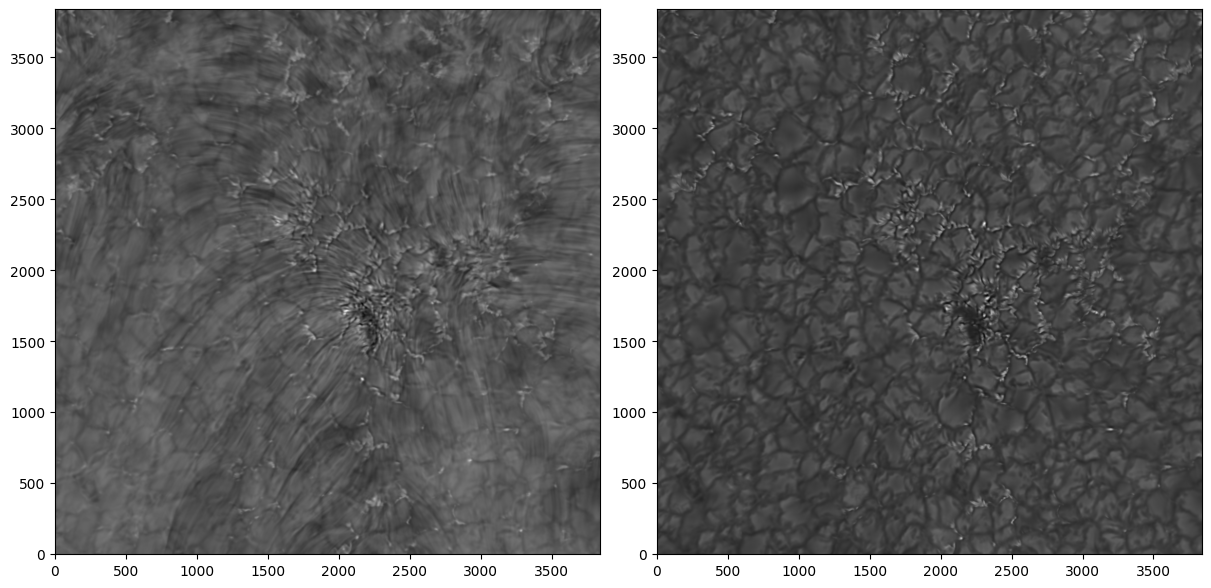

In [7]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
ax1.imshow(Hbeta_test_image_0, cmap="gray", origin="lower")
ax2.imshow(Gband_test_image_0, cmap="gray", origin="lower")

In [32]:
ImageBlinker(Hbeta_test_image_0, Gband_test_image_0, cmap1="gray", cmap2="gray",)

In [43]:
Hbeta_test_image_0_destretched, Gband_test_image_0_destretched = destretchSeq(
    np.array([Hbeta_test_image_0, Gband_test_image_0]),
    [128,96],
    rMean=3,
    globalTrack=[1500,1500,256]
)

In [44]:
ImageBlinker(Hbeta_test_image_0_destretched, Gband_test_image_0_destretched, cmap1="gray", cmap2="gray",)

In [45]:
def ridge_enhance(image, method="meijering", sigmas=range(1, 5), black_ridges=True):
    if method == "meijering":
        return meijering(image, sigmas=sigmas, black_ridges=black_ridges)
    if method == "sato":
        return sato(image, sigmas=sigmas, black_ridges=black_ridges)
    if method == "frangi":
        return frangi(image, sigmas=sigmas, black_ridges=black_ridges)
    raise ValueError(f"Unknown method: {method}")

In [46]:
def make_mask(enhanced, low_pct=70, high_pct=92, min_size=50, open_radius=2):
    lo, hi = np.nanpercentile(enhanced, (low_pct, high_pct))
    mask = filters.apply_hysteresis_threshold(enhanced, lo, hi)
    mask = remove_small_objects(mask, min_size=min_size)
    if open_radius > 0:
        mask = morphology.binary_opening(mask, morphology.disk(open_radius))
    return mask

In [47]:
Hbeta_ridge_enhanced = ridge_enhance(Hbeta_test_image_0_destretched, method="sato")
Gband_ridge_enhanced = ridge_enhance(Gband_test_image_0_destretched, method="sato")

In [98]:
Hbeta_mask = make_mask(Hbeta_ridge_enhanced, low_pct=70, high_pct=92, min_size=60, open_radius=2)

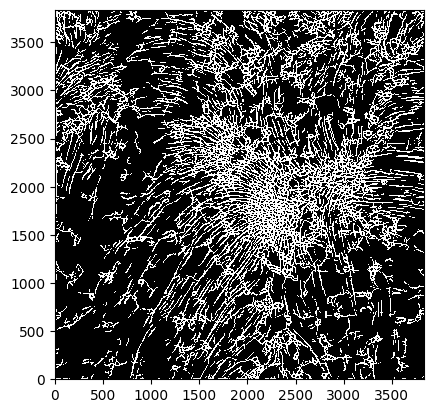

In [99]:
plt.imshow(Hbeta_mask, origin="lower", interpolation="none", cmap="gray")

In [50]:
def coalign_masks(mask_true, mask_bg, upsample_factor=1):
    """
    Coalign mask_bg to mask_true using phase cross-correlation.
    Precision is limited to 1 pixel (upsample_factor=1).

    Parameters
    ----------
    mask_true : 2D bool array
    mask_bg   : 2D bool array
    upsample_factor : int
        Kept at 1 for integer-pixel precision. Increase for sub-pixel
        (but shift will then be rounded to nearest integer anyway).

    Returns
    -------
    mask_bg_shifted : 2D bool array
        mask_bg shifted to align with mask_true.
    shift : (row_shift, col_shift) float tuple
        Detected shift in pixels (rows, cols). Positive = moved right/down.
    """
    shift_detected, _, _ = phase_cross_correlation(
        mask_true.astype(float),
        mask_bg.astype(float),
        upsample_factor=upsample_factor,
    )

    # Round to nearest integer pixel
    shift_int = np.round(shift_detected).astype(int)

    # Shift mask_bg — use order=0 (nearest neighbour) to keep it binary
    mask_bg_shifted = nd_shift(
        mask_bg.astype(float),
        shift=shift_int,
        order=0,          # nearest-neighbour: no interpolation artefacts
        mode='constant',
        cval=0,
    ).astype(bool)

    return mask_bg_shifted, tuple(shift_int)

In [100]:
Gband_mask = make_mask(Gband_ridge_enhanced, low_pct=80, high_pct=90, min_size=60, open_radius=2)
Gband_mask, _ = coalign_masks(Hbeta_mask, Gband_mask, upsample_factor=1)

ImageBlinker(Hbeta_mask, Gband_mask, cmap1="gray", cmap2="gray",
    norm1=ImageNormalize(vmin=0, vmax=1), norm2=ImageNormalize(vmin=0, vmax=1),)

In [116]:
def merge_target_func(params, img1, img2):
    a, b = params
    merge_image = img1 + a*img2 + b*img2*img2
    return np.nanstd(merge_image)

In [109]:
Hbeta_test_image_0_destretched_norm = ImageNormalize()(Hbeta_test_image_0_destretched)
Gband_test_image_0_destretched_norm = ImageNormalize()(Gband_test_image_0_destretched)

In [110]:
print(np.nanmean(Hbeta_test_image_0_destretched_norm[0:600,0:600]), np.nanmean(Gband_test_image_0_destretched_norm[0:600,0:600]))

0.37828885950295127 0.252622128377546


In [117]:
merge_result = minimize(merge_target_func, x0=[-1.5, 0], args=(Hbeta_test_image_0_destretched_norm, Gband_test_image_0_destretched_norm),
        bounds=[(-5, 5), (-5, 5)])

In [118]:
merge_result.x

array([-0.62332714,  0.05745266])

In [119]:
Hbeta_Gband_merge_test_image_0 = Hbeta_test_image_0_destretched_norm + \
    merge_result.x[0]*Gband_test_image_0_destretched_norm + \
    merge_result.x[1]*Gband_test_image_0_destretched_norm**2

/cluster/home/zhuyin/sunpy_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


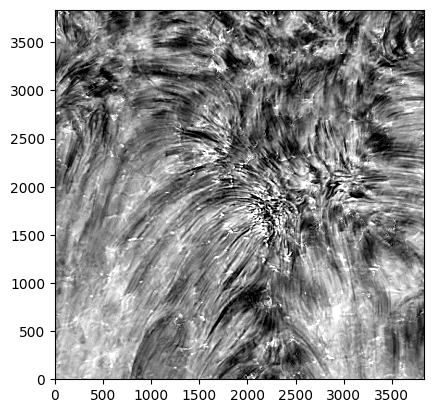

In [120]:
plt.imshow(Hbeta_Gband_merge_test_image_0, origin="lower", interpolation="none", cmap="gray",
        vmin=np.nanpercentile(Hbeta_Gband_merge_test_image_0, 1), 
        vmax=np.nanpercentile(Hbeta_Gband_merge_test_image_0, 99))

In [121]:
merge_enhanced = ridge_enhance(Hbeta_Gband_merge_test_image_0, method="sato")
merge_mask = make_mask(merge_enhanced, low_pct=70, high_pct=92, min_size=60, open_radius=2)

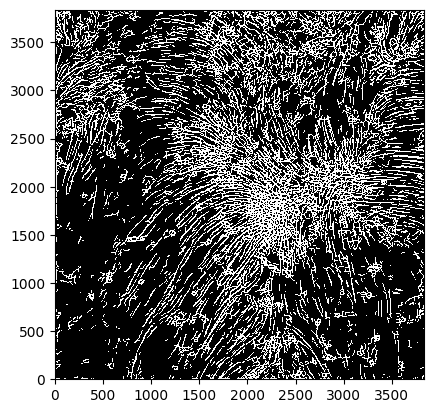

In [122]:
plt.imshow(merge_mask, origin="lower", interpolation="none", cmap="gray",)

In [105]:
ImageBlinker(merge_mask, Gband_mask, cmap1="gray", cmap2="gray",
norm1=ImageNormalize(vmin=0, vmax=1), norm2=ImageNormalize(vmin=0, vmax=1),)

In [54]:
def _find_junction_pixels(skel):
    """Pixels with 3 or more neighbours in the skeleton (8-connectivity)."""
    from scipy.ndimage import convolve
    kernel   = np.ones((3, 3), dtype=int)
    neighbor_count = convolve(skel.astype(int), kernel, mode='constant', cval=0)
    # A junction pixel is a skeleton pixel with ≥3 neighbours (including itself → ≥4)
    return skel & (neighbor_count >= 4)

def _split_at_junctions(skel, junction_mask):
    """Remove junction pixels from skeleton, label remaining arc segments."""
    skel_cut = skel & ~junction_mask
    labeled  = measure.label(skel_cut, connectivity=2)
    return labeled

def _reattach_junctions(skel_keep, junction_mask, labeled_arcs,
                         kept_arc_ids, dilation_radius=1):
    """
    Re-attach junction pixels that are within dilation_radius of any kept arc.
    Using the same dilation_radius as the BG overlap test ensures that
    junctions consumed by the dilated BG mask are still recovered.
    """
    kept_arcs_mask  = np.isin(labeled_arcs, list(kept_arc_ids))
    kept_dilated    = binary_dilation(kept_arcs_mask, disk(dilation_radius))
    junction_reattach = junction_mask & kept_dilated
    return skel_keep | junction_reattach

def filter_mask_by_background(mask_true, mask_bg,
                               dilation_radius=2,
                               min_overlap_fraction=0.5,
                               min_overlap_length=20):
    """
    Remove regions from mask_true that correspond to background skeleton
    components. Closed loops are first split at junction pixels into
    individual arc segments for finer-grained filtering. Junction pixels
    are re-attached if at least one neighbouring arc is kept.

    Parameters
    ----------
    mask_true : 2D bool array
    mask_bg   : 2D bool array
    dilation_radius : int
        Tolerance for skeleton misalignment.
    min_overlap_fraction : float in [0, 1]
        Fraction of arc pixels overlapping dilated BG skeleton to trigger removal.
    min_overlap_length : int
        Number of overlapping skeleton pixels to trigger removal.
        Both thresholds must be exceeded for removal.

    Returns
    -------
    mask_filtered : 2D bool array
    debug : dict
    """
    # --- Step 1: skeletonize ---
    skel_true = skeletonize(mask_true)
    skel_bg   = skeletonize(mask_bg)

    # --- Step 2: find and cut at junction pixels ---
    junction_mask = _find_junction_pixels(skel_true)
    labeled_arcs  = _split_at_junctions(skel_true, junction_mask)
    n_arcs        = labeled_arcs.max()

    # --- Step 3: dilate BG skeleton for overlap tolerance ---
    bg_dilated = binary_dilation(skel_bg, disk(dilation_radius))

    # --- Step 4: filter each arc segment ---
    skel_keep   = np.zeros_like(skel_true)
    skel_remove = np.zeros_like(skel_true)
    kept_arc_ids    = set()
    removed_arc_ids = set()

    for arc_id in range(1, n_arcs + 1):
        arc           = labeled_arcs == arc_id
        arc_pixels    = arc.sum()
        if arc_pixels == 0:
            continue

        overlap_pixels   = (arc & bg_dilated).sum()
        overlap_fraction = overlap_pixels / arc_pixels
        overlap_length   = overlap_pixels

        if (overlap_fraction > min_overlap_fraction and
                overlap_length   > min_overlap_length):
            skel_remove |= arc
            removed_arc_ids.add(arc_id)
        else:
            skel_keep   |= arc
            kept_arc_ids.add(arc_id)

    # --- Step 5: re-attach junction pixels touching at least one kept arc ---
    skel_keep = _reattach_junctions(skel_keep, junction_mask,
                                     labeled_arcs, kept_arc_ids,
                                     dilation_radius=dilation_radius)

    # --- Step 6: reconstruct mask from filtered skeleton ---
    dist = distance_transform_edt(mask_true)

    def _reconstruct(skel):
        if not skel.any():
            return np.zeros(mask_true.shape, dtype=bool)
        coords = np.argwhere(skel)
        radii  = dist[skel]
        result = np.zeros(mask_true.shape, dtype=bool)
        for radius in np.unique(np.round(radii).astype(int)):
            pts      = coords[np.round(radii).astype(int) == radius]
            pts_mask = np.zeros(mask_true.shape, dtype=bool)
            pts_mask[pts[:, 0], pts[:, 1]] = True
            result  |= binary_dilation(pts_mask, disk(radius))
        return result & mask_true

    region_keep   = _reconstruct(skel_keep)
    region_remove = _reconstruct(skel_remove)

    junction_preserved = region_remove & region_keep
    mask_filtered      = (region_keep | junction_preserved) & mask_true

    debug = dict(
        skel_true          = skel_true,
        skel_bg            = skel_bg,
        junction_mask      = junction_mask,
        labeled_arcs       = labeled_arcs,
        skel_kept          = skel_keep,
        skel_removed       = skel_remove,
        region_kept        = region_keep,
        region_removed     = region_remove,
        junction_preserved = junction_preserved,
        n_arcs             = n_arcs,
        n_kept             = len(kept_arc_ids),
        n_removed          = len(removed_arc_ids),
    )

    return mask_filtered, debug

In [124]:
Hbeta_mask_reconstructed, debug = filter_mask_by_background(merge_mask, Gband_mask,
                                                  dilation_radius=3, min_overlap_fraction=0.,
                                                  min_overlap_length=1)

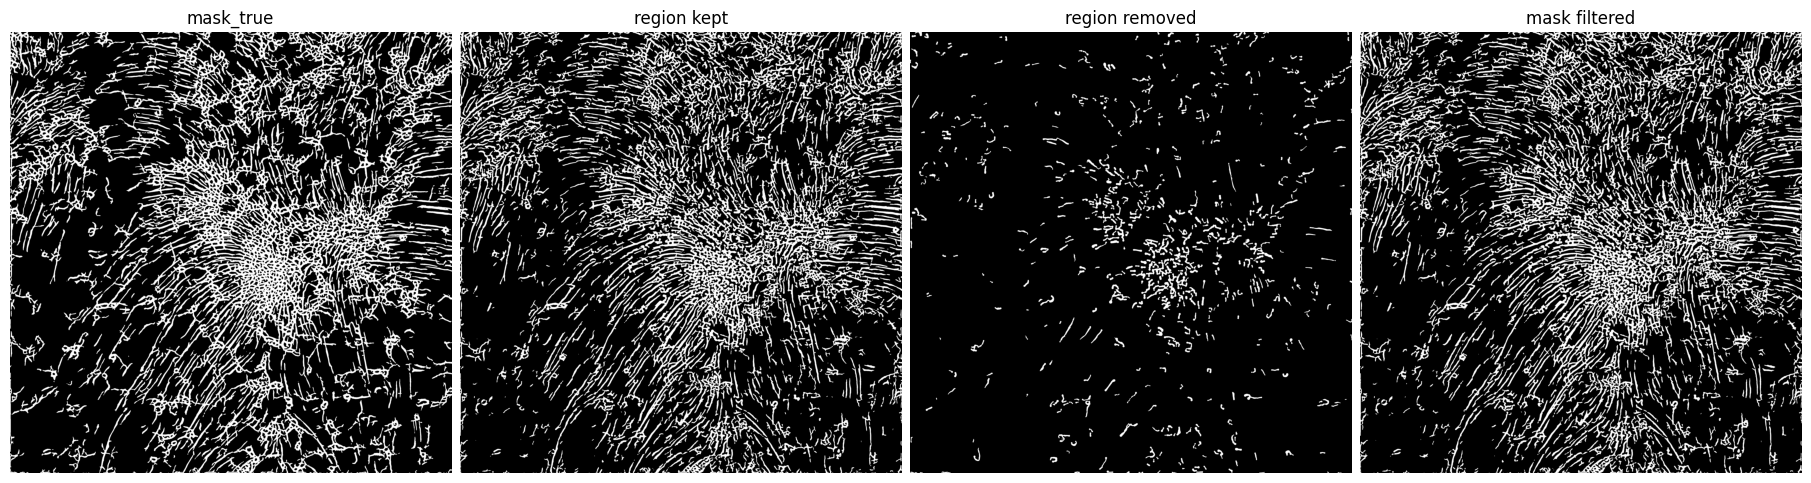

In [107]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), constrained_layout=True)
axes[0].imshow(merge_mask,cmap='gray',origin='lower'); axes[0].set_title('mask_true')
axes[1].imshow(debug['region_kept'],cmap='gray', origin='lower'); axes[1].set_title('region kept')
axes[2].imshow(debug['region_removed'],cmap='gray', origin='lower'); axes[2].set_title('region removed')
axes[3].imshow(Hbeta_mask_reconstructed,cmap='gray', origin='lower'); axes[3].set_title('mask filtered')
for ax in axes: ax.axis('off')